Running RANSAC Line Fitting...
Line Parameters: a=-0.7106, b=-0.7036, d=-1.3413
Line Inliers: 54/100

Remaining points for circle fitting: 46
Running RANSAC Circle Fitting...
Circle Parameters: center=(1.9559, 3.0419), radius=10.0101
Circle Inliers: 46/46


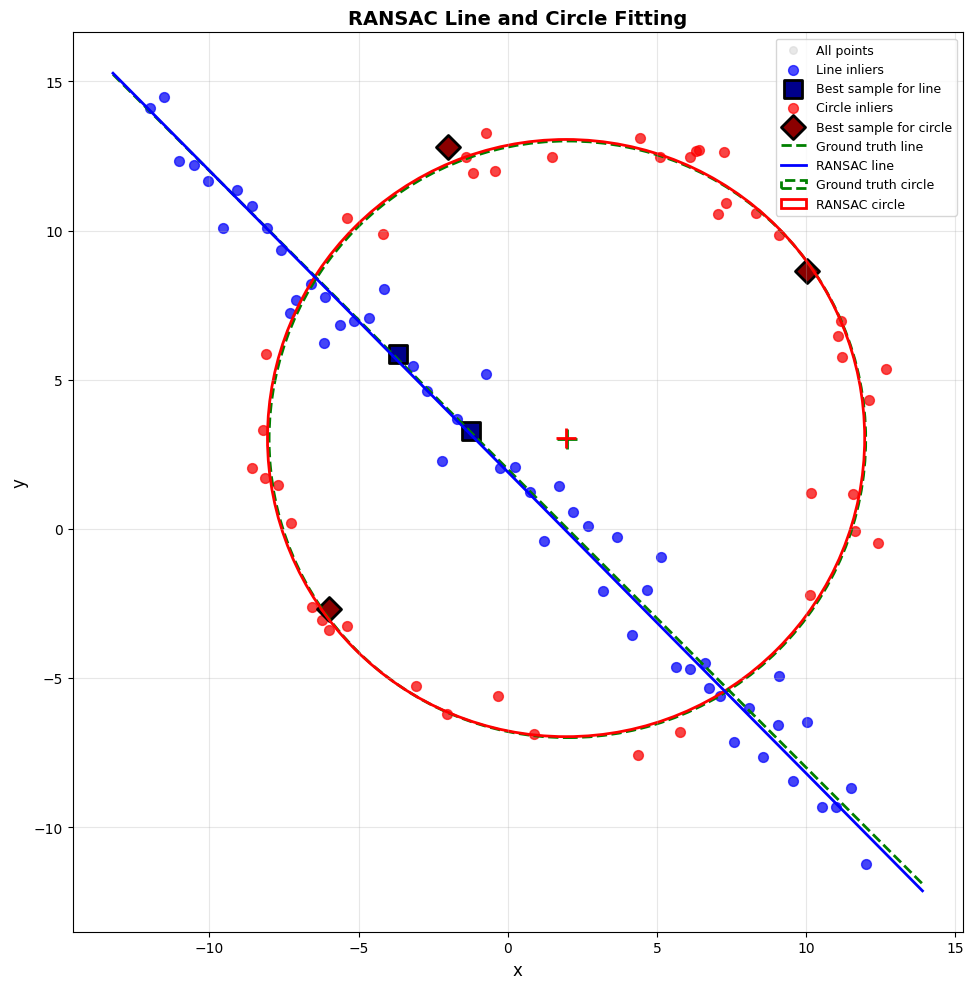


Part (d): What happens if we fit the circle first?

If the circle is fitted first instead of the line:
1. Higher outlier ratio: The circle RANSAC would face ~50% outliers (line points),
   requiring more iterations for robust estimation.
2. Computational cost: More RANSAC iterations needed to achieve 99% confidence
   of finding a good model.
3. Contaminated second fit: After removing circle inliers, the remaining points
   would include both line points AND circle outliers, making line fitting harder.
4. Sequential dependency: The simpler model (line, 2 points) is easier to fit first,
   followed by the more complex model (circle, 3 points).
5. Better separation: Fitting line first removes a well-defined subset, leaving
   cleaner data for circle fitting.



In [1]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ==================== Data Generation (from assignment) ====================
np.random.seed(42)  # For reproducibility
N = 100
half_n = N // 2

# Generate circle points
r = 10
x0_gt, y0_gt = 2, 3  # Center
s = r / 16
t = np.random.uniform(0, 2*np.pi, half_n)
n = s * np.random.randn(half_n)
x, y = x0_gt + (r + n)*np.cos(t), y0_gt + (r + n)*np.sin(t)
X_circ = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Generate line points (y = -x + 2)
s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s*np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n, 1), y.reshape(half_n, 1)))

# Combine all points
X = np.vstack((X_circ, X_line))

# ==================== RANSAC Line Fitting ====================
def fit_line_from_two_points(p1, p2):
    """
    Fit a line from two points and return parameters [a, b, d]
    where [a,b]^T is unit normal and d is perpendicular distance from origin
    """
    # Direction vector
    dx = p2[0] - p1[0]
    dy = p2[1] - p1[1]
    
    # Normal vector (perpendicular to direction)
    a = -dy
    b = dx
    
    # Normalize to unit normal
    norm = np.sqrt(a**2 + b**2)
    a = a / norm
    b = b / norm
    
    # Compute d (perpendicular distance from origin)
    d = a * p1[0] + b * p1[1]
    
    return a, b, d

def compute_line_distances(X, a, b, d):
    """Compute normal distance from points to line"""
    distances = np.abs(a * X[:, 0] + b * X[:, 1] - d)
    return distances

def ransac_line(X, threshold=2.0, max_iterations=1000, min_inliers=40):
    """
    RANSAC algorithm for line fitting
    Returns: best line parameters, inlier mask, best sample points
    """
    best_inliers = 0
    best_params = None
    best_mask = None
    best_sample = None
    
    n_points = X.shape[0]
    
    for i in range(max_iterations):
        # Randomly sample 2 points
        idx = np.random.choice(n_points, 2, replace=False)
        sample_points = X[idx]
        
        # Fit line to these 2 points
        a, b, d = fit_line_from_two_points(sample_points[0], sample_points[1])
        
        # Compute distances for all points
        distances = compute_line_distances(X, a, b, d)
        
        # Count inliers
        inlier_mask = distances < threshold
        n_inliers = np.sum(inlier_mask)
        
        # Update best model if this is better
        if n_inliers > best_inliers:
            best_inliers = n_inliers
            best_params = (a, b, d)
            best_mask = inlier_mask
            best_sample = sample_points.copy()
    
    # Refit line using all inliers (Least Squares refinement)
    if best_mask is not None and np.sum(best_mask) >= 2:
        inlier_points = X[best_mask]
        # Use SVD for total least squares fitting
        centroid = np.mean(inlier_points, axis=0)
        centered = inlier_points - centroid
        U, S, Vt = np.linalg.svd(centered)
        normal = Vt[-1, :]  # Last row of Vt is the normal
        a, b = normal[0], normal[1]
        # Normalize
        norm = np.sqrt(a**2 + b**2)
        a, b = a/norm, b/norm
        d = a * centroid[0] + b * centroid[1]
        best_params = (a, b, d)
        
        # Recompute inliers with refined line
        distances = compute_line_distances(X, a, b, d)
        best_mask = distances < threshold
    
    return best_params, best_mask, best_sample

# ==================== RANSAC Circle Fitting ====================
def fit_circle_from_three_points(p1, p2, p3):
    """
    Fit a circle from three points
    Returns: center [xc, yc] and radius r
    """
    ax, ay = p1[0], p1[1]
    bx, by = p2[0], p2[1]
    cx, cy = p3[0], p3[1]
    
    # Calculate circle center using perpendicular bisectors
    D = 2 * (ax * (by - cy) + bx * (cy - ay) + cx * (ay - by))
    
    if abs(D) < 1e-10:  # Points are collinear
        return None, None
    
    ux = ((ax**2 + ay**2) * (by - cy) + (bx**2 + by**2) * (cy - ay) + (cx**2 + cy**2) * (ay - by)) / D
    uy = ((ax**2 + ay**2) * (cx - bx) + (bx**2 + by**2) * (ax - cx) + (cx**2 + cy**2) * (bx - ax)) / D
    
    r = np.sqrt((ux - ax)**2 + (uy - ay)**2)
    
    return np.array([ux, uy]), r

def compute_circle_radial_errors(X, center, radius):
    """Compute radial errors from points to circle"""
    distances_to_center = np.sqrt((X[:, 0] - center[0])**2 + (X[:, 1] - center[1])**2)
    radial_errors = np.abs(distances_to_center - radius)
    return radial_errors

def circle_objective(params, points):
    """Objective function for circle optimization"""
    xc, yc, r = params
    errors = compute_circle_radial_errors(points, np.array([xc, yc]), r)
    return np.sum(errors**2)

def ransac_circle(X, threshold=2.0, max_iterations=1000, min_inliers=40):
    """
    RANSAC algorithm for circle fitting
    Returns: best circle parameters, inlier mask, best sample points
    """
    best_inliers = 0
    best_params = None
    best_mask = None
    best_sample = None
    
    n_points = X.shape[0]
    
    for i in range(max_iterations):
        # Randomly sample 3 points
        idx = np.random.choice(n_points, 3, replace=False)
        sample_points = X[idx]
        
        # Fit circle to these 3 points
        center, radius = fit_circle_from_three_points(
            sample_points[0], sample_points[1], sample_points[2]
        )
        
        if center is None:  # Points are collinear
            continue
        
        # Compute radial errors for all points
        radial_errors = compute_circle_radial_errors(X, center, radius)
        
        # Count inliers
        inlier_mask = radial_errors < threshold
        n_inliers = np.sum(inlier_mask)
        
        # Update best model if this is better
        if n_inliers > best_inliers:
            best_inliers = n_inliers
            best_params = (center, radius)
            best_mask = inlier_mask
            best_sample = sample_points.copy()
    
    # Optimize circle using all inliers
    if best_mask is not None and np.sum(best_mask) >= 3:
        inlier_points = X[best_mask]
        center, radius = best_params
        
        # Initial guess
        x0 = [center[0], center[1], radius]
        
        # Optimize
        result = minimize(circle_objective, x0, args=(inlier_points,), method='Nelder-Mead')
        
        if result.success:
            xc_opt, yc_opt, r_opt = result.x
            best_params = (np.array([xc_opt, yc_opt]), r_opt)
            
            # Recompute inliers with optimized circle
            radial_errors = compute_circle_radial_errors(X, best_params[0], best_params[1])
            best_mask = radial_errors < threshold
    
    return best_params, best_mask, best_sample

# ==================== Main Execution ====================
print("Running RANSAC Line Fitting...")
line_params, line_mask, line_sample = ransac_line(X, threshold=2.0, max_iterations=1000)
a, b, d = line_params
print(f"Line Parameters: a={a:.4f}, b={b:.4f}, d={d:.4f}")
print(f"Line Inliers: {np.sum(line_mask)}/{len(X)}")

# Remove line inliers for circle fitting
X_remaining = X[~line_mask]
print(f"\nRemaining points for circle fitting: {len(X_remaining)}")

print("Running RANSAC Circle Fitting...")
circle_params, circle_mask_remaining, circle_sample = ransac_circle(
    X_remaining, threshold=2.0, max_iterations=1000
)
center, radius = circle_params
print(f"Circle Parameters: center=({center[0]:.4f}, {center[1]:.4f}), radius={radius:.4f}")
print(f"Circle Inliers: {np.sum(circle_mask_remaining)}/{len(X_remaining)}")

# Map circle mask back to original X
circle_mask = np.zeros(len(X), dtype=bool)
circle_mask[~line_mask] = circle_mask_remaining

# ==================== Visualization ====================
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

# Plot all points
ax.scatter(X[:, 0], X[:, 1], c='lightgray', s=30, alpha=0.5, label='All points')

# Plot line inliers
ax.scatter(X[line_mask, 0], X[line_mask, 1], c='blue', s=50, alpha=0.7, label='Line inliers')

# Plot best 2-point sample for line
ax.scatter(line_sample[:, 0], line_sample[:, 1], c='darkblue', s=150, 
           marker='s', edgecolors='black', linewidths=2, label='Best sample for line')

# Plot circle inliers
ax.scatter(X[circle_mask, 0], X[circle_mask, 1], c='red', s=50, alpha=0.7, label='Circle inliers')

# Plot best 3-point sample for circle
ax.scatter(circle_sample[:, 0], circle_sample[:, 1], c='darkred', s=150, 
           marker='D', edgecolors='black', linewidths=2, label='Best sample for circle')

# Plot ground truth line (y = -x + 2)
x_min, x_max = ax.get_xlim()
x_gt = np.array([x_min, x_max])
y_gt = -x_gt + 2
ax.plot(x_gt, y_gt, 'g--', linewidth=2, label='Ground truth line')

# Plot RANSAC estimated line
# Line equation: ax + by = d
if abs(b) > 1e-6:
    y_ransac = (d - a * x_gt) / b
    ax.plot(x_gt, y_ransac, 'b-', linewidth=2, label='RANSAC line')
else:
    x_ransac = d / a
    ax.axvline(x=x_ransac, color='b', linewidth=2, label='RANSAC line')

# Plot ground truth circle
circle_gt = plt.Circle((x0_gt, y0_gt), r, color='green', fill=False, 
                        linewidth=2, linestyle='--', label='Ground truth circle')
ax.add_patch(circle_gt)
ax.plot(x0_gt, y0_gt, 'g+', markersize=15, markeredgewidth=2)

# Plot RANSAC estimated circle
circle_ransac = plt.Circle((center[0], center[1]), radius, color='red', 
                           fill=False, linewidth=2, label='RANSAC circle')
ax.add_patch(circle_ransac)
ax.plot(center[0], center[1], 'r+', markersize=15, markeredgewidth=2)

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('RANSAC Line and Circle Fitting', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
plt.tight_layout()
plt.savefig('ransac_fitting_result.png', dpi=150, bbox_inches='tight')
plt.show()

# ==================== Discussion for Part (d) ====================
print("\n" + "="*70)
print("Part (d): What happens if we fit the circle first?")
print("="*70)
print("""
If the circle is fitted first instead of the line:
1. Higher outlier ratio: The circle RANSAC would face ~50% outliers (line points),
   requiring more iterations for robust estimation.
2. Computational cost: More RANSAC iterations needed to achieve 99% confidence
   of finding a good model.
3. Contaminated second fit: After removing circle inliers, the remaining points
   would include both line points AND circle outliers, making line fitting harder.
4. Sequential dependency: The simpler model (line, 2 points) is easier to fit first,
   followed by the more complex model (circle, 3 points).
5. Better separation: Fitting line first removes a well-defined subset, leaving
   cleaner data for circle fitting.
""")
